## Analysis of the results

In [35]:
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np

# Add src to path for imports
sys.path.insert(0, str(Path.cwd().parent.parent / "src"))
from generation.visualization import show_isometric_view, show_orthographic_views

## Load original tasks

In [36]:
input_path = Path.cwd().parent.parent / "datasets" / "kaggle_benchmark" 

files_voxels = {
    path.stem: path
    for path in input_path.glob("*.json")
    if path.stem.startswith("orthographic_dataset_")
}

print(f"Found {len(files_voxels)} files in {input_path}")

ds_tasks = []
for name, path in files_voxels.items():
    with open(path, "r") as f:
        raw = json.load(f)
        print(f"Loaded dataset with {len(raw['tasks'])} records from {path.name}")
        df = pd.DataFrame(raw['tasks'][:50])  # Limit to first 50 tasks
        # Extract scene_size from filename (e.g., "orthographic_dataset_5v_fixed_3_tasks.json" -> 3)
        scene_size = int(path.stem.split('_')[4])
        df["scene_size"] = scene_size
        ds_tasks.append(df)

df_tasks = pd.concat(ds_tasks, ignore_index=True)
print(f"Combined tasks dataset has {len(df_tasks)} records")

Found 6 files in /Users/joost/vscode/ai-measuring-toward-agi-competition/datasets/kaggle_benchmark
Loaded dataset with 200 records from orthographic_dataset_5v_fixed_5_tasks.json
Loaded dataset with 200 records from orthographic_dataset_mc_fixed_5_tasks.json
Loaded dataset with 200 records from orthographic_dataset_5v_fixed_4_tasks.json
Loaded dataset with 200 records from orthographic_dataset_mc_fixed_3_tasks.json
Loaded dataset with 200 records from orthographic_dataset_mc_fixed_4_tasks.json
Loaded dataset with 200 records from orthographic_dataset_5v_fixed_3_tasks.json
Combined tasks dataset has 300 records


In [37]:
df_tasks.iloc[0]

id                                                             42_001
voxels              [[[0, 0, 0, 0, 0], [0, 0, 0, 9, 9], [0, 0, 0, ...
input               {'front': [[9, 5, 5, 0, 7], [9, 5, 0, 0, 0], [...
answer              [[0, 9, 7, 0, 0], [0, 9, 5, 9, 0], [0, 0, 5, 3...
scene_size                                                          5
multiple_choices                                                  NaN
Name: 0, dtype: object

## Load results

In [38]:
def get_results_files(input_path: Path, multiple_choice: bool = False) -> dict[str, Path]:
    input_files = {
        path.stem: path
        for path in input_path.glob("*.json")
        if (path.stem.startswith("results_5v") if not multiple_choice else path.stem.startswith("results_mc"))
    }
    return input_files

In [39]:
files_mc = get_results_files(Path.cwd().parent.parent / "results_from_kaggle", multiple_choice=True)
print(f"Found {len(files_mc)} multiple choice files")
files_5v = get_results_files(Path.cwd().parent.parent / "results_from_kaggle", multiple_choice=False)
print(f"Found {len(files_5v)} 5 views files")

Found 3 multiple choice files
Found 3 5 views files


In [40]:
def open_results(path: Path) -> pd.DataFrame:
    with open(path, "r") as f:
        dataset = json.load(f)
        print(f"Loaded dataset with {len(dataset)} records from {path.name}")
    df = pd.DataFrame(dataset)
    # Extract scene_size from filename (e.g., "results_mc_fixed_3_tasks_50.json" -> 3)
    scene_size = int(path.stem.split('_')[3])
    df["scene_size"] = scene_size
    task_type = path.stem.split('_')[1]  # "mc" or "5v"
    df["task_type"] = task_type
    return df

In [41]:
# Load all multiple-choice files and concatenate
ds = []
for name, path in files_mc.items():
    tmp = open_results(path)
    ds.append(tmp)

# Load all 5-view files and concatenate
for name, path in files_5v.items():
    tmp = open_results(path)
    ds.append(tmp)

# Combine all dataframes
df_results = pd.concat(ds, ignore_index=True)

print(f"\nTotal MC records: {len(df_results[df_results['task_type'] == 'mc'])}")
print(f"Total 5V records: {len(df_results[df_results['task_type'] == '5v'])}")

Loaded dataset with 550 records from results_mc_fixed_3_tasks_50.json
Loaded dataset with 550 records from results_mc_fixed_4_tasks_50.json
Loaded dataset with 220 records from results_mc_fixed_5_tasks_20.json
Loaded dataset with 550 records from results_5v_fixed_3_tasks_50.json
Loaded dataset with 550 records from results_5v_fixed_4_tasks_50.json
Loaded dataset with 220 records from results_5v_fixed_5_tasks_20.json

Total MC records: 1320
Total 5V records: 1320


## Tasks with error

In [95]:
df_error = df_results[(df_results['predicted_answer'] == 'ERROR')]
print(f"\nTotal records with ERROR: {len(df_error)}, percentage: {len(df_error) / len(df_results) * 100:.2f}% of all records ({len(df_results)})")


Total records with ERROR: 69, percentage: 2.61% of all records (2640)


In [90]:
df_error

,id,model,predicted_answer,time_elapsed,is_correct,scene_size,task_type,correctness
53,42_004,zai/glm-5,ERROR,531.0,False,3,mc,NaN
56,42_007,zai/glm-5,ERROR,301.3,False,3,mc,NaN
84,42_035,zai/glm-5,ERROR,301.3,False,3,mc,NaN
86,42_037,zai/glm-5,ERROR,301.3,False,3,mc,NaN
92,42_043,zai/glm-5,ERROR,283.7,False,3,mc,NaN
...,...,...,...,...,...,...,...,...
2448,42_009,zai/glm-5,ERROR,301.5,NaN,5,5v,0.0
2455,42_016,zai/glm-5,ERROR,301.4,NaN,5,5v,0.0
2457,42_018,zai/glm-5,ERROR,301.4,NaN,5,5v,0.0
2458,42_019,zai/glm-5,ERROR,39.6,NaN,5,5v,0.0


In [98]:
error_counts = df_results[df_results['predicted_answer'] == 'ERROR'].groupby(['model', 'task_type']).size().reset_index(name='error_count')

# Pivot to show MC and 5V side by side
error_pivot = error_counts.pivot(index='model', columns='task_type', values='error_count').fillna(0).astype(int)
error_pivot.columns = ['Multiple Choice', '5 Views']
error_pivot = error_pivot.reset_index()

# Calculate totals
error_pivot['Total'] = error_pivot['Multiple Choice'] + error_pivot['5 Views']

error_pivot = error_pivot.sort_values('Total', ascending=False)
print("\nError counts by model and task type:")
print(error_pivot.to_markdown(index=False))


Error counts by model and task type:
| model                               |   Multiple Choice |   5 Views |   Total |
|:------------------------------------|------------------:|----------:|--------:|
| zai/glm-5                           |                16 |        30 |      46 |
| qwen/qwen3-next-80b-a3b-thinking    |                 8 |         5 |      13 |
| google/gemma-4-26b-a4b              |                 2 |         7 |       9 |
| anthropic/claude-sonnet-4-6@default |                 0 |         1 |       1 |


So especially 

### 5 views tasks flipped
The benchmark is mild towards flipped results: 0.33 for horizontally and vertically flipped, 0.17 for both flipped. How often tdid this occur:

In [105]:
df_flipped = df_results[
    (df_results['task_type'] == '5v') & 
    (df_results['predicted_answer'] != 'ERROR') & 
    (pd.to_numeric(df_results['correctness'], errors='coerce') > 0) & 
    (pd.to_numeric(df_results['correctness'], errors='coerce') < 1)
]
total_5v = len(df_results[df_results['task_type'] == '5v'])
print(f"Flipped results count: {len(df_flipped)} in total 5V records ({total_5v}), percentage: {len(df_flipped) / total_5v * 100:.2f}%")

Flipped results count: 34 in total 5V records (1320), percentage: 2.58%


## Analysis of results

In [44]:
def accuracy_by_model_and_scene_size_and_task_type(df: pd.DataFrame, scene_size: int, task_type: str) -> pd.DataFrame:
    # Filter for the specified scene_size and task_type, then calculate accuracy per model
    df_filtered = df[(df['scene_size'] == scene_size) & (df['task_type'] == task_type)]
    
    # Determine which column to use for accuracy calculation
    accuracy_col = 'is_correct' if task_type == 'mc' else 'correctness'
    
    # Perform aggregations separately and combine
    accuracy_stats = df_filtered.groupby('model')[accuracy_col].agg(['mean', 'size']).reset_index()
    accuracy_stats.columns = ['model', 'accuracy', 'count']
    
    error_stats = df_filtered.groupby('model')['predicted_answer'].apply(lambda x: (x == 'ERROR').sum()).reset_index()
    error_stats.columns = ['model', 'errors']
    error_stats['errors'] = error_stats['errors'].astype(int)
    
    runtime_stats = df_filtered.groupby('model')['time_elapsed'].mean().reset_index()
    runtime_stats.columns = ['model', 'runtime']
    
    # Merge all statistics
    result = accuracy_stats.merge(error_stats, on='model').merge(runtime_stats, on='model')
    
    # Ensure numeric types before rounding
    result['accuracy'] = pd.to_numeric(result['accuracy'], errors='coerce').round(2)
    result['runtime'] = pd.to_numeric(result['runtime'], errors='coerce').round(1)
    result = result.sort_values('model', ascending=True)
    
    return result

### Size 3x3x3

In [45]:
#accuracy_by_model_and_scene_size_and_task_type(df_results, scene_size=3, task_type='5v')
print(accuracy_by_model_and_scene_size_and_task_type(df_results, scene_size=3, task_type='5v').to_markdown(index=False))

| model                               |   accuracy |   count |   errors |   runtime |
|:------------------------------------|-----------:|--------:|---------:|----------:|
| anthropic/claude-opus-4-6@default   |       0.62 |      50 |        0 |      17.8 |
| anthropic/claude-sonnet-4-6@default |       0.81 |      50 |        0 |      15.9 |
| deepseek-ai/deepseek-r1-0528        |       0.52 |      50 |        0 |      87.4 |
| deepseek-ai/deepseek-v3.2           |       0.22 |      50 |        0 |       2.2 |
| google/gemini-3.1-pro-preview       |       0.96 |      50 |        0 |      39.4 |
| google/gemma-4-26b-a4b              |       0.86 |      50 |        0 |     291.5 |
| openai/gpt-5.4-2026-03-05           |       0.53 |      50 |        0 |       1.1 |
| openai/gpt-5.4-mini-2026-03-17      |       0.15 |      50 |        0 |       0.6 |
| qwen/qwen3-235b-a22b-instruct-2507  |       0.18 |      50 |        0 |       0.5 |
| qwen/qwen3-next-80b-a3b-thinking    |       0.76 |  

In [ ]:
print(accuracy_by_model_and_scene_size_and_task_type(df_results, scene_size=3, task_type='mc').to_markdown(index=False))

######## SEE SECTION CORRECTTION BELOW FOR UPDATE !!!!!!

| model                               |   accuracy |   count |   errors |   runtime |
|:------------------------------------|-----------:|--------:|---------:|----------:|
| anthropic/claude-opus-4-6@default   |       0.34 |      50 |        0 |       1.2 |
| anthropic/claude-sonnet-4-6@default |       0.76 |      50 |        1 |      13.5 |
| deepseek-ai/deepseek-r1-0528        |       0.92 |      50 |        0 |      72.2 |
| deepseek-ai/deepseek-v3.2           |       0.24 |      50 |        0 |       1.3 |
| google/gemini-3.1-pro-preview       |       1    |      50 |        0 |      29   |
| google/gemma-4-26b-a4b              |       0.98 |      50 |        0 |     276.7 |
| openai/gpt-5.4-2026-03-05           |       0.24 |      50 |        0 |       0.6 |
| openai/gpt-5.4-mini-2026-03-17      |       0.24 |      50 |        0 |       0.4 |
| qwen/qwen3-235b-a22b-instruct-2507  |       0.26 |      50 |        0 |       0.5 |
| qwen/qwen3-next-80b-a3b-thinking    |       0.82 |  

### Size 4x4x4

In [47]:
print(accuracy_by_model_and_scene_size_and_task_type(df_results, scene_size=4, task_type='5v').to_markdown(index=False))

| model                               |   accuracy |   count |   errors |   runtime |
|:------------------------------------|-----------:|--------:|---------:|----------:|
| anthropic/claude-opus-4-6@default   |       0.4  |      50 |        0 |      21.7 |
| anthropic/claude-sonnet-4-6@default |       0.38 |      50 |        0 |      19.8 |
| deepseek-ai/deepseek-r1-0528        |       0.46 |      50 |        0 |     121.9 |
| deepseek-ai/deepseek-v3.2           |       0    |      50 |        0 |       2.8 |
| google/gemini-3.1-pro-preview       |       0.92 |      50 |        0 |      95.2 |
| google/gemma-4-26b-a4b              |       0.44 |      50 |        2 |     605.5 |
| openai/gpt-5.4-2026-03-05           |       0.26 |      50 |        0 |       1.1 |
| openai/gpt-5.4-mini-2026-03-17      |       0.05 |      50 |        0 |       0.7 |
| qwen/qwen3-235b-a22b-instruct-2507  |       0.01 |      50 |        0 |       0.8 |
| qwen/qwen3-next-80b-a3b-thinking    |       0.44 |  

In [48]:
print(accuracy_by_model_and_scene_size_and_task_type(df_results, scene_size=4, task_type='mc').to_markdown(index=False))

| model                               |   accuracy |   count |   errors |   runtime |
|:------------------------------------|-----------:|--------:|---------:|----------:|
| anthropic/claude-opus-4-6@default   |       0.22 |      50 |        0 |       3.1 |
| anthropic/claude-sonnet-4-6@default |       0.64 |      50 |        0 |      19.6 |
| deepseek-ai/deepseek-r1-0528        |       0.86 |      50 |        0 |     122.8 |
| deepseek-ai/deepseek-v3.2           |       0.28 |      50 |        0 |       2   |
| google/gemini-3.1-pro-preview       |       0.98 |      50 |        0 |      44.4 |
| google/gemma-4-26b-a4b              |       0.82 |      50 |        7 |     460.4 |
| openai/gpt-5.4-2026-03-05           |       0.24 |      50 |        0 |       0.6 |
| openai/gpt-5.4-mini-2026-03-17      |       0.24 |      50 |        0 |       0.6 |
| qwen/qwen3-235b-a22b-instruct-2507  |       0.2  |      50 |        0 |       0.4 |
| qwen/qwen3-next-80b-a3b-thinking    |       0.84 |  

### Size 5x5x5

In [49]:
print(accuracy_by_model_and_scene_size_and_task_type(df_results, scene_size=5, task_type='5v').to_markdown(index=False))

| model                               |   accuracy |   count |   errors |   runtime |
|:------------------------------------|-----------:|--------:|---------:|----------:|
| anthropic/claude-opus-4-6@default   |       0.3  |      20 |        0 |      23.6 |
| anthropic/claude-sonnet-4-6@default |       0.3  |      20 |        0 |      19.9 |
| deepseek-ai/deepseek-r1-0528        |       0.43 |      20 |        0 |     149.8 |
| deepseek-ai/deepseek-v3.2           |       0.05 |      20 |        0 |       3   |
| google/gemini-3.1-pro-preview       |       0.9  |      20 |        0 |     110.2 |
| google/gemma-4-26b-a4b              |       0.45 |      20 |        0 |     663.2 |
| openai/gpt-5.4-2026-03-05           |       0.03 |      20 |        0 |       1.7 |
| openai/gpt-5.4-mini-2026-03-17      |       0    |      20 |        0 |       0.9 |
| qwen/qwen3-235b-a22b-instruct-2507  |       0    |      20 |        0 |       0.9 |
| qwen/qwen3-next-80b-a3b-thinking    |       0.1  |  

In [50]:
print(accuracy_by_model_and_scene_size_and_task_type(df_results, scene_size=5, task_type='mc').to_markdown(index=False))

| model                               |   accuracy |   count |   errors |   runtime |
|:------------------------------------|-----------:|--------:|---------:|----------:|
| anthropic/claude-opus-4-6@default   |       0.25 |      20 |        0 |       1.3 |
| anthropic/claude-sonnet-4-6@default |       0.45 |      20 |        0 |      20.4 |
| deepseek-ai/deepseek-r1-0528        |       0.9  |      20 |        0 |     136.3 |
| deepseek-ai/deepseek-v3.2           |       0.2  |      20 |        0 |       1.8 |
| google/gemini-3.1-pro-preview       |       1    |      20 |        0 |      63.5 |
| google/gemma-4-26b-a4b              |       0.9  |      20 |        0 |     374.1 |
| openai/gpt-5.4-2026-03-05           |       0.2  |      20 |        0 |       0.7 |
| openai/gpt-5.4-mini-2026-03-17      |       0.35 |      20 |        0 |       0.6 |
| qwen/qwen3-235b-a22b-instruct-2507  |       0.25 |      20 |        0 |       0.6 |
| qwen/qwen3-next-80b-a3b-thinking    |       0.55 |  

### Summary

In [88]:
# Summary table for 5v tasks across all scene sizes
summary_5v = []
for size in [3, 4, 5]:
    df_temp = accuracy_by_model_and_scene_size_and_task_type(df_results, scene_size=size, task_type='5v')[['model', 'accuracy']]
    df_temp = df_temp.rename(columns={'accuracy': f'{size}x{size}x{size}'})
    summary_5v.append(df_temp)

# Merge all sizes
result_5v = summary_5v[0]
for df in summary_5v[1:]:
    result_5v = result_5v.merge(df, on='model', how='outer')

# Convert accuracy to percentage with % symbol
result_5v['3x3x3'] = (result_5v['3x3x3'] * 100).round(0).astype(int).astype(str) + '%'
result_5v['4x4x4'] = (result_5v['4x4x4'] * 100).round(0).astype(int).astype(str) + '%'
result_5v['5x5x5'] = (result_5v['5x5x5'] * 100).round(0).astype(int).astype(str) + '%'

result_5v = result_5v.sort_values('model', ascending=True)
print(result_5v.to_markdown(index=False))

# Export to Excel
output_path = Path.cwd().parent.parent / "results_from_kaggle" / "summary_5v.xlsx"
result_5v.to_excel(output_path, index=False)
print(f"\nExported to {output_path}")

| model                               | 3x3x3   | 4x4x4   | 5x5x5   |
|:------------------------------------|:--------|:--------|:--------|
| anthropic/claude-opus-4-6@default   | 62%     | 40%     | 30%     |
| anthropic/claude-sonnet-4-6@default | 81%     | 38%     | 30%     |
| deepseek-ai/deepseek-r1-0528        | 52%     | 46%     | 43%     |
| deepseek-ai/deepseek-v3.2           | 22%     | 0%      | 5%      |
| google/gemini-3.1-pro-preview       | 96%     | 92%     | 90%     |
| google/gemma-4-26b-a4b              | 86%     | 44%     | 45%     |
| openai/gpt-5.4-2026-03-05           | 53%     | 26%     | 3%      |
| openai/gpt-5.4-mini-2026-03-17      | 15%     | 5%      | 0%      |
| qwen/qwen3-235b-a22b-instruct-2507  | 18%     | 1%      | 0%      |
| qwen/qwen3-next-80b-a3b-thinking    | 76%     | 44%     | 10%     |
| zai/glm-5                           | 98%     | 74%     | 45%     |

Exported to /Users/joost/vscode/ai-measuring-toward-agi-competition/results_from_kaggle/s

In [89]:
# Summary table for mc tasks across all scene sizes
summary_mc = []
for size in [3, 4, 5]:
    df_temp = accuracy_by_model_and_scene_size_and_task_type(df_results, scene_size=size, task_type='mc')[['model', 'accuracy']]
    df_temp = df_temp.rename(columns={'accuracy': f'{size}x{size}x{size}'})
    summary_mc.append(df_temp)

# Merge all sizes
result_mc = summary_mc[0]
for df in summary_mc[1:]:
    result_mc = result_mc.merge(df, on='model', how='outer')

# Convert accuracy to percentage with % symbol
result_mc['3x3x3'] = (result_mc['3x3x3'] * 100).round(0).astype(int).astype(str) + '%'
result_mc['4x4x4'] = (result_mc['4x4x4'] * 100).round(0).astype(int).astype(str) + '%'
result_mc['5x5x5'] = (result_mc['5x5x5'] * 100).round(0).astype(int).astype(str) + '%'

result_mc = result_mc.sort_values('model', ascending=True)
print(result_mc.to_markdown(index=False))

# Export to Excel
output_path = Path.cwd().parent.parent / "results_from_kaggle" / "summary_mc.xlsx"
result_mc.to_excel(output_path, index=False)
print(f"\nExported to {output_path}")

| model                               | 3x3x3   | 4x4x4   | 5x5x5   |
|:------------------------------------|:--------|:--------|:--------|
| anthropic/claude-opus-4-6@default   | 34%     | 22%     | 25%     |
| anthropic/claude-sonnet-4-6@default | 76%     | 64%     | 45%     |
| deepseek-ai/deepseek-r1-0528        | 92%     | 86%     | 90%     |
| deepseek-ai/deepseek-v3.2           | 24%     | 28%     | 20%     |
| google/gemini-3.1-pro-preview       | 100%    | 98%     | 100%    |
| google/gemma-4-26b-a4b              | 98%     | 82%     | 90%     |
| openai/gpt-5.4-2026-03-05           | 24%     | 24%     | 20%     |
| openai/gpt-5.4-mini-2026-03-17      | 24%     | 24%     | 35%     |
| qwen/qwen3-235b-a22b-instruct-2507  | 26%     | 20%     | 25%     |
| qwen/qwen3-next-80b-a3b-thinking    | 82%     | 84%     | 55%     |
| zai/glm-5                           | 90%     | 70%     | 50%     |

Exported to /Users/joost/vscode/ai-measuring-toward-agi-competition/results_from_kaggle/s

## Runtime impact
The runtime increases with the scene sizes.

In [53]:
# Summary table for 5v tasks across all scene sizes
summary_5v = []
for size in [3, 4, 5]:
    df_temp = accuracy_by_model_and_scene_size_and_task_type(df_results, scene_size=size, task_type='5v')[['model', 'runtime']]
    df_temp = df_temp.rename(columns={'runtime': f'{size}x{size}x{size}'})
    summary_5v.append(df_temp)

# Merge all sizes
result_5v = summary_5v[0]
for df in summary_5v[1:]:
    result_5v = result_5v.merge(df, on='model', how='outer')

# Calculate normalized increase as percentage
result_5v['4x4x4 increase'] = (((result_5v['4x4x4'] - result_5v['3x3x3']) / result_5v['3x3x3']) * 100).round(1)
result_5v['5x5x5 increase'] = (((result_5v['5x5x5'] - result_5v['3x3x3']) / result_5v['3x3x3']) * 100).round(1)

result_5v = result_5v.sort_values('model', ascending=True)
print(result_5v.to_markdown(index=False))

| model                               |   3x3x3 |   4x4x4 |   5x5x5 |   4x4x4 increase |   5x5x5 increase |
|:------------------------------------|--------:|--------:|--------:|-----------------:|-----------------:|
| anthropic/claude-opus-4-6@default   |    17.8 |    21.7 |    23.6 |             21.9 |             32.6 |
| anthropic/claude-sonnet-4-6@default |    15.9 |    19.8 |    19.9 |             24.5 |             25.2 |
| deepseek-ai/deepseek-r1-0528        |    87.4 |   121.9 |   149.8 |             39.5 |             71.4 |
| deepseek-ai/deepseek-v3.2           |     2.2 |     2.8 |     3   |             27.3 |             36.4 |
| google/gemini-3.1-pro-preview       |    39.4 |    95.2 |   110.2 |            141.6 |            179.7 |
| google/gemma-4-26b-a4b              |   291.5 |   605.5 |   663.2 |            107.7 |            127.5 |
| openai/gpt-5.4-2026-03-05           |     1.1 |     1.1 |     1.7 |              0   |             54.5 |
| openai/gpt-5.4-mini-2026-0

In [54]:
# Summary table for mc tasks across all scene sizes
summary_mc = []
for size in [3, 4, 5]:
    df_temp = accuracy_by_model_and_scene_size_and_task_type(df_results, scene_size=size, task_type='mc')[['model', 'runtime']]
    df_temp = df_temp.rename(columns={'runtime': f'{size}x{size}x{size}'})
    summary_mc.append(df_temp)

# Merge all sizes
result_mc = summary_mc[0]
for df in summary_mc[1:]:
    result_mc = result_mc.merge(df, on='model', how='outer')

# Calculate normalized increase as percentage
result_mc['4x4x4 increase'] = (((result_mc['4x4x4'] - result_mc['3x3x3']) / result_mc['3x3x3']) * 100).round(1)
result_mc['5x5x5 increase'] = (((result_mc['5x5x5'] - result_mc['3x3x3']) / result_mc['3x3x3']) * 100).round(1)

result_mc = result_mc.sort_values('model', ascending=True)
print(result_mc.to_markdown(index=False))

| model                               |   3x3x3 |   4x4x4 |   5x5x5 |   4x4x4 increase |   5x5x5 increase |
|:------------------------------------|--------:|--------:|--------:|-----------------:|-----------------:|
| anthropic/claude-opus-4-6@default   |     1.2 |     3.1 |     1.3 |            158.3 |              8.3 |
| anthropic/claude-sonnet-4-6@default |    13.5 |    19.6 |    20.4 |             45.2 |             51.1 |
| deepseek-ai/deepseek-r1-0528        |    72.2 |   122.8 |   136.3 |             70.1 |             88.8 |
| deepseek-ai/deepseek-v3.2           |     1.3 |     2   |     1.8 |             53.8 |             38.5 |
| google/gemini-3.1-pro-preview       |    29   |    44.4 |    63.5 |             53.1 |            119   |
| google/gemma-4-26b-a4b              |   276.7 |   460.4 |   374.1 |             66.4 |             35.2 |
| openai/gpt-5.4-2026-03-05           |     0.6 |     0.6 |     0.7 |              0   |             16.7 |
| openai/gpt-5.4-mini-2026-0

zero answers in mc
flipped in 5v
kind of runtime errors

## Most wrongly predicted tasks

In [55]:
def most_wrongly_predicted_tasks_mc(df: pd.DataFrame, scene_size: int) -> pd.DataFrame:
    # Filter for the specified scene_size and task_type, then count incorrect predictions by id
    incorrect_by_id = df[(df['scene_size'] == scene_size) & (df['task_type'] == 'mc') & (df['is_correct'] == False)].groupby('id').size().reset_index(name='incorrect_count')
    return incorrect_by_id.sort_values('incorrect_count', ascending=False)

def most_wrongly_predicted_tasks_5v(df: pd.DataFrame, scene_size: int) -> pd.DataFrame:
    # Select records where correctness is 0 (incorrect), then filter for the specified scene_size and task_type
    incorrect_zeros = df[(df['scene_size'] == scene_size) & (df['task_type'] == '5v') & (df['correctness'] == 0)]
    incorrect_by_id = incorrect_zeros.groupby('id').size().reset_index(name='incorrect_count')
    return incorrect_by_id.sort_values('incorrect_count', ascending=False)

def get_task(df: pd.DataFrame, task_id: str, scene_size: int, task_type: str) -> pd.DataFrame:
    if task_type == '5v':
        return df[(df['id'] == task_id) & (df['scene_size'] == scene_size) & (df['multiple_choices'].isna())]
    else:
        return df[(df['id'] == task_id) & (df['scene_size'] == scene_size) & (df['multiple_choices'].notna())]
    

### Multiple choice

In [56]:
df_most_incorrect_mc_scene_3 = most_wrongly_predicted_tasks_mc(df_results, scene_size=3)
df_most_incorrect_mc_scene_3.head()

,id,incorrect_count
29,42_030,11
40,42_041,10
21,42_022,10
34,42_035,8
35,42_036,7


In [57]:
task = get_task(df_tasks, task_id="42_030", scene_size=3, task_type='mc')
print(task['answer'])
task['multiple_choices'].values[0]


179    2
Name: answer, dtype: object


{'1': [[5, 0, 0], [5, 0, 8], [5, 0, 0]],
 '2': [[5, 0, 0], [5, 0, 8], [5, 0, 0]],
 '3': [[0, 0, 5], [8, 0, 5], [0, 0, 5]],
 '4': [[0, 0, 5], [0, 0, 0], [8, 0, 0]]}

In [58]:
task['multiple_choices'].values[0]['1'] == task['multiple_choices'].values[0]['2']

True

Hm, I understand the issue: answers 1 and 2 are both correct! We need to to review all MC answers to check if there are more of these cases where 2 or more choices are correct.

In [59]:
def check_multiple_choice_duplicates(df: pd.DataFrame, scene_size: int) -> list[dict]:
    df_mc = df_tasks[(df_tasks['scene_size'] == scene_size) & (df_tasks['multiple_choices'].notna())]
    duplicates = []

    for idx, row in df_mc.iterrows():
        task_id = row['id']
        correct_answer = row['answer']
        multiple_choices = row['multiple_choices']
        
        # Get the correct choice as array
        correct_choice = np.array(multiple_choices[str(correct_answer)])
        
        # Check if correct answer matches any other choice
        for choice_num in ['1', '2', '3', '4']:
            if choice_num == str(correct_answer):
                continue  # Skip comparing with itself
            
            other_choice = np.array(multiple_choices[choice_num])
            
            # Check if arrays are equal
            if np.array_equal(correct_choice, other_choice):
                duplicates.append({
                    'task_id': task_id,
                    'correct_answer': correct_answer,
                    'duplicate_choice': int(choice_num)
                })
        
    return duplicates


In [60]:
check_multiple_choice_duplicates(df_tasks, scene_size=3)

[{'task_id': '42_020', 'correct_answer': 1, 'duplicate_choice': 2},
 {'task_id': '42_022', 'correct_answer': 4, 'duplicate_choice': 1},
 {'task_id': '42_029', 'correct_answer': 2, 'duplicate_choice': 3},
 {'task_id': '42_030', 'correct_answer': 2, 'duplicate_choice': 1},
 {'task_id': '42_038', 'correct_answer': 2, 'duplicate_choice': 4},
 {'task_id': '42_041', 'correct_answer': 4, 'duplicate_choice': 1},
 {'task_id': '42_042', 'correct_answer': 2, 'duplicate_choice': 3}]

In [61]:
check_multiple_choice_duplicates(df_tasks, scene_size=4), check_multiple_choice_duplicates(df_tasks, scene_size=4)

([], [])

So no errors in the scene size 4 and 5, so we only have to review the results of scene size 3.

In [84]:
duplicates_3 = check_multiple_choice_duplicates(df_tasks, scene_size=3)
df_mc_3 = df_results[(df_results['scene_size'] == 3) & (df_results['task_type'] == 'mc')]
print(f"Found {len(df_mc_3)} tasks.")
count = 0

for idx, result in df_mc_3.iterrows():
    if result['id'] in [dup['task_id'] for dup in duplicates_3]:
        alternative_answer = [dup for dup in duplicates_3 if dup['task_id'] == result['id']][0]
        #print(f"Task {result['id']} has a duplicate correct answer. Predicted: {result['predicted_answer']}, duplicate: {alternative_answer['duplicate_choice']}, correct answer: {alternative_answer['correct_answer']}")
        if result['predicted_answer'] == alternative_answer['duplicate_choice']:
            count += 1
            # Modify df_results directly using .loc to make changes persistent
            df_results.loc[idx, 'is_correct'] = True

print(f"Number of corrections made: {count}")

Found 550 tasks.
Number of corrections made: 31


These are the results including corrections:

In [87]:
print(accuracy_by_model_and_scene_size_and_task_type(df_results, scene_size=3, task_type='mc').to_markdown(index=False))

| model                               |   accuracy |   count |   errors |   runtime |
|:------------------------------------|-----------:|--------:|---------:|----------:|
| anthropic/claude-opus-4-6@default   |       0.34 |      50 |        0 |       1.2 |
| anthropic/claude-sonnet-4-6@default |       0.76 |      50 |        1 |      13.5 |
| deepseek-ai/deepseek-r1-0528        |       0.92 |      50 |        0 |      72.2 |
| deepseek-ai/deepseek-v3.2           |       0.24 |      50 |        0 |       1.3 |
| google/gemini-3.1-pro-preview       |       1    |      50 |        0 |      29   |
| google/gemma-4-26b-a4b              |       0.98 |      50 |        0 |     276.7 |
| openai/gpt-5.4-2026-03-05           |       0.24 |      50 |        0 |       0.6 |
| openai/gpt-5.4-mini-2026-03-17      |       0.24 |      50 |        0 |       0.4 |
| qwen/qwen3-235b-a22b-instruct-2507  |       0.26 |      50 |        0 |       0.5 |
| qwen/qwen3-next-80b-a3b-thinking    |       0.82 |  

### 5 views

In [82]:
df_most_incorrect_5v_scene_3 = most_wrongly_predicted_tasks_5v(df_results, scene_size=3)
df_most_incorrect_5v_scene_3.head()

,id,incorrect_count
12,42_013,11
35,42_036,9
15,42_016,8
34,42_035,8
6,42_007,8


Let's review why 42_013 goes wrong for all models.

In [65]:
task = get_task(df_tasks, task_id="42_013", scene_size=3, task_type='5v')

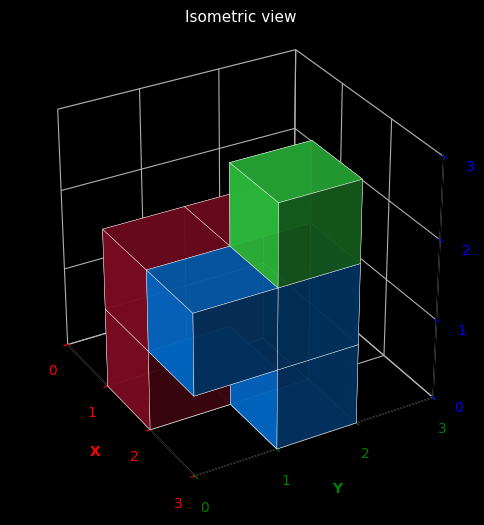

In [66]:
show_isometric_view(np.array(np.array(task['voxels'].values[0])))

In [67]:
df_5v_3_predictions = df_results[(df_results['scene_size'] == 3) & (df_results['task_type'] == '5v') & (df_results['id'] == "42_013")][['model', 'predicted_answer', 'correctness']]
predicted_views = {}
for idx, row in df_5v_3_predictions.iterrows():
    predicted_views[row['model']] = np.array(row['predicted_answer'])
predicted_views

{'zai/glm-5': array([[0, 3, 0],
        [9, 1, 0],
        [1, 1, 0]]),
 'anthropic/claude-sonnet-4-6@default': array([[0, 3, 0],
        [1, 9, 0],
        [1, 9, 0]]),
 'qwen/qwen3-next-80b-a3b-thinking': array([[0, 3, 0],
        [9, 1, 0],
        [1, 9, 0]]),
 'anthropic/claude-opus-4-6@default': array([[0, 3, 0],
        [1, 1, 0],
        [1, 1, 0]]),
 'openai/gpt-5.4-2026-03-05': array([[0, 3, 0],
        [0, 9, 9],
        [0, 9, 9]]),
 'deepseek-ai/deepseek-r1-0528': array([[0, 3, 0],
        [9, 1, 0],
        [1, 9, 0]]),
 'deepseek-ai/deepseek-v3.2': array([[0, 0, 0],
        [9, 9, 1],
        [9, 9, 1]]),
 'qwen/qwen3-235b-a22b-instruct-2507': array([[3, 0, 0],
        [9, 9, 0],
        [9, 9, 0]]),
 'openai/gpt-5.4-mini-2026-03-17': array([[0, 9, 3],
        [0, 9, 1],
        [0, 0, 0]]),
 'google/gemma-4-26b-a4b': array([[0, 3, 0],
        [1, 9, 0],
        [1, 1, 0]]),
 'google/gemini-3.1-pro-preview': array([[0, 3, 0],
        [1, 1, 0],
        [1, 1, 0]])}

KeyError: 'zai/glm-5'

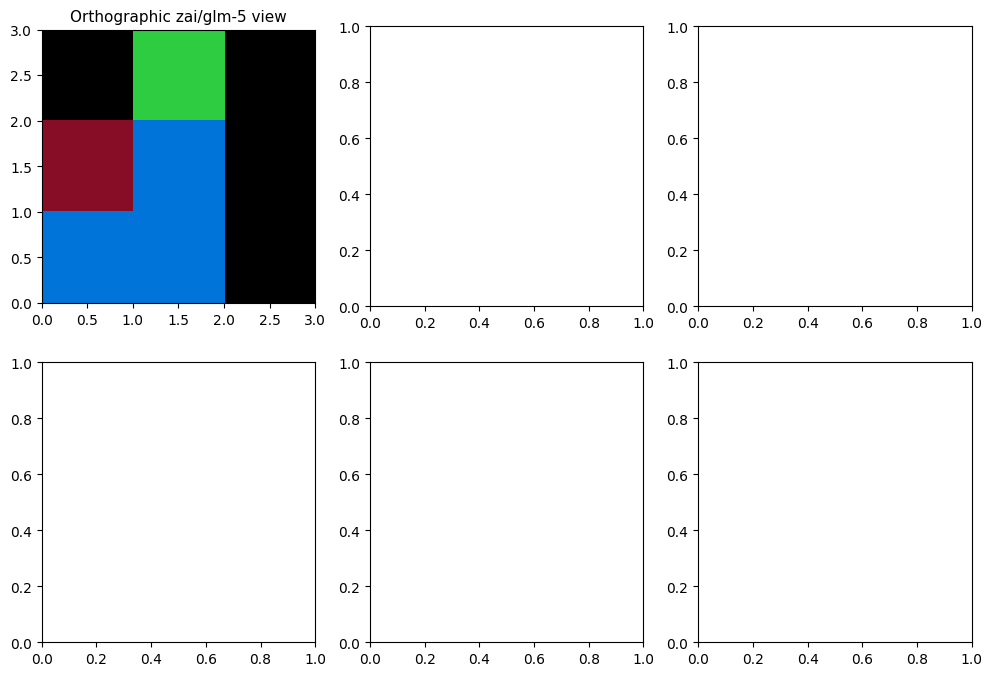

In [68]:
show_orthographic_views(predicted_views)

Yes, that already gives a clue: Based on the 5 views it is impossible to predict the right view unambiguously...

In [ ]:
df_most_incorrect_5v_scene_4 = most_wrongly_predicted_tasks_5v(df_results, scene_size=4)
df_most_incorrect_5v_scene_4.head()

,id,incorrect_count
41,42_042,9
30,42_031,9
0,42_001,8
17,42_018,8
34,42_035,8


In [ ]:
df_most_incorrect_5v_scene_4 = most_wrongly_predicted_tasks_5v(df, scene_size=4)
df_most_incorrect_5v_scene_4.head()

,id,incorrect_count
41,42_042,9
30,42_031,9
0,42_001,8
17,42_018,8
34,42_035,8
